-> 1. Business Problem

Customer churn is a critical challenge for companies like telecom, banking, and subscription services.

-> Problem:

Customers are leaving the service, leading to revenue loss.

-->Why this matters:
Impact	Explanation
Revenue Loss	Losing customers reduces profit
High Cost	Acquiring new customers is expensive
Retention Needed	Keeping customers is cheaper

-> Objective:

-->Build a machine learning model that predicts whether a customer will churn.

-> 2. Machine Learning Problem
🔹 Problem Type:
Item	Value
Type	Binary Classification
Target	Churn
Classes	Yes (1), No (0)
🔹 Input Features:

Customer-related attributes:

Demographics → gender, senior citizen
Account info → tenure
Services → internet, phone, streaming
Billing → MonthlyCharges, TotalCharges
🔹 Output:

--> Predict probability of churn

Example:

Customer A → 0.85 (likely to churn)
Customer B → 0.12 (unlikely to churn)
-> 3. Evaluation Metric (VERY IMPORTANT)
ROC-AUC Score

-->The model is evaluated using:

Area Under ROC Curve

--> ROC-AUC Meaning:
Score	Interpretation
0.5	Random
0.7	Good
0.8+	Strong
0.85+	Excellent 
-> 4. Dataset Description
--> Files Provided:
File	Description
train.csv	Training data (with target)
test.csv	Test data (no target)
sample_submission.csv	Format for submission

-> 5. Solution Goal
Build a model that:
--> Identifies high-risk customers
--> Predicts churn probability accurately
--> Generalizes well to unseen data



#### Import the Libraries

In [3]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from warnings import filterwarnings
filterwarnings('ignore')

pd.set_option('display.max_columns',None)

In [4]:
train=pd.read_csv(r'train.csv')

In [5]:
test=pd.read_csv(r'test.csv')
sample=pd.read_csv(r'sample_submission.csv')

In [6]:
train

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,No
594190,594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,No
594191,594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,No
594192,594192,Female,0,No,No,32,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.00,2847.20,No


In [7]:
test

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254650,848844,Male,0,Yes,Yes,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),19.95,1443.65
254651,848845,Male,1,Yes,No,16,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,100.15,1563.50
254652,848846,Male,0,Yes,No,35,Yes,Yes,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),105.80,3132.75
254653,848847,Female,0,No,No,25,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),20.25,511.25


#### Data Understandings

In [8]:
train.shape

(594194, 21)

In [9]:
train.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [10]:
train.tail()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
594189,594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,No
594190,594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,No
594191,594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,No
594192,594192,Female,0,No,No,32,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.00,2847.20,No
594193,594193,Female,1,Yes,No,2,Yes,No,DSL,No,No,No,No,Yes,No,Month-to-month,Yes,Electronic check,54.55,108.05,Yes


In [11]:
train.isnull().sum()

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
train.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177262,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


In [13]:
train.dtypes

id                    int64
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [14]:
print(train.shape)
print(test.shape)
print(sample.shape)

(594194, 21)
(254655, 20)
(254655, 2)


###### Columns Details 

In [15]:
train.columns

Index(['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [16]:
test.columns

Index(['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')

In [17]:
a= train.columns.to_list()
b= test.columns.to_list()
for i in a:
    if i not in b:
        print(i)

Churn


In [18]:
#### Check for Dtypes

In [19]:
train.dtypes

id                    int64
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [20]:
test.dtypes

id                    int64
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
dtype: object

In [21]:
train.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177262,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


Observations
1.min tenure that a customer uses the service is 1 month 
2. max tenture that a customer uses the service is 72 months 
3. min monthlyCharges is 18.25 for 1 month 
4. max monthlyCharges is 118.75 for the 72 months 

In [22]:
test.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,254655.000000,254655.00000,254655.000000,254655.000000,254655.000000
mean,721521.000000,0.11362,37.279716,66.130803,2544.617351
std,73512.710738,0.31735,24.777625,31.104139,2348.124379
min,594194.000000,0.00000,1.000000,18.300000,18.800000
25%,657857.500000,0.00000,13.000000,30.150000,677.625000
50%,721521.000000,0.00000,36.000000,74.350000,1468.750000
75%,785184.500000,0.00000,62.000000,91.100000,4317.300000
max,848848.000000,1.00000,72.000000,118.750000,8684.800000


In [23]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [24]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254655 entries, 0 to 254654
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                254655 non-null  int64  
 1   gender            254655 non-null  object 
 2   SeniorCitizen     254655 non-null  int64  
 3   Partner           254655 non-null  object 
 4   Dependents        254655 non-null  object 
 5   tenure            254655 non-null  int64  
 6   PhoneService      254655 non-null  object 
 7   MultipleLines     254655 non-null  object 
 8   InternetService   254655 non-null  object 
 9   OnlineSecurity    254655 non-null  object 
 10  OnlineBackup      254655 non-null  object 
 11  DeviceProtection  254655 non-null  object 
 12  TechSupport       254655 non-null  object 
 13  StreamingTV       254655 non-null  object 
 14  StreamingMovies   254655 non-null  object 
 15  Contract          254655 non-null  object 
 16  PaperlessBilling  25

In [25]:
train.isnull().sum()

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [26]:
test.isnull().sum()

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

In [27]:
train[train.duplicated()]

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [28]:
test[test.duplicated()]

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges


#### EDA

In [29]:
train['Churn'].value_counts()

Churn
No     460377
Yes    133817
Name: count, dtype: int64

In [38]:
train['Churn'].value_counts(normalize=True)*100

Churn
No     77.479241
Yes    22.520759
Name: proportion, dtype: float64

In [39]:
'''There is imbalance in the Churn columns that is No     77.479241
Yes    22.520759 so we need to normlaize those so ROC-AUC Score '''

'There is imbalance in the Churn columns that is No     77.479241\nYes    22.520759 so we need to normlaize those so ROC-AUC Score '

In [40]:
#### Gender

In [41]:
train['gender'].value_counts()

gender
Female    298738
Male      295456
Name: count, dtype: int64

In [42]:
train.groupby('gender')['Churn'].value_counts()

gender  Churn
Female  No       230615
        Yes       68123
Male    No       229762
        Yes       65694
Name: count, dtype: int64

In [43]:
train.groupby('gender')['Churn'].value_counts(normalize=True)*100

gender  Churn
Female  No       77.196406
        Yes      22.803594
Male    No       77.765217
        Yes      22.234783
Name: proportion, dtype: float64

In [44]:
#### Stats for checking the relationships

In [45]:
from scipy.stats import (chi2,chi2_contingency)

In [46]:
import statsmodels.formula.api as smf

In [47]:
train[['gender','Churn']].value_counts()

gender  Churn
Female  No       230615
Male    No       229762
Female  Yes       68123
Male    Yes       65694
Name: count, dtype: int64

In [48]:
ct_blue=pd.crosstab(train.gender,train.Churn)

In [49]:
ct_blue

Churn,No,Yes
gender,,
Female,230615,68123
Male,229762,65694


In [50]:
chi2_contingency(ct_blue)

Chi2ContingencyResult(statistic=27.511126194516983, pvalue=1.561933705084728e-07, dof=1, expected_freq=array([[231459.93434131,  67278.06565869],
       [228917.06565869,  66538.93434131]]))

In [51]:
train['SeniorCitizen'].value_counts()

SeniorCitizen
0    526395
1     67799
Name: count, dtype: int64

In [52]:
train['SeniorCitizen'].value_counts(normalize=True)*100

SeniorCitizen
0    88.589754
1    11.410246
Name: proportion, dtype: float64

In [53]:
train.dtypes[train.dtypes=='O']

gender              object
Partner             object
Dependents          object
PhoneService        object
MultipleLines       object
InternetService     object
OnlineSecurity      object
OnlineBackup        object
DeviceProtection    object
TechSupport         object
StreamingTV         object
StreamingMovies     object
Contract            object
PaperlessBilling    object
PaymentMethod       object
Churn               object
dtype: object

In [54]:
train.describe(include='O')

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Female,Yes,No,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,No
freq,298738,309554,414362,557893,283384,272386,289474,250083,247377,288571,240301,241435,298918,365579,215372,460377


In [55]:
ind=train.dtypes[train.dtypes=='O'].index

In [56]:
ind

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

The unique values are: ['Male' 'Female']
The number of unique values are: 2
The column name is: gender
gender
Female    298738
Male      295456
Name: count, dtype: int64
gender
Female    50.276172
Male      49.723828
Name: proportion, dtype: float64
gender  Churn
Female  No       230615
        Yes       68123
Male    No       229762
        Yes       65694
Name: count, dtype: int64
gender  Churn
Female  No       77.196406
        Yes      22.803594
Male    No       77.765217
        Yes      22.234783
Name: proportion, dtype: float64
There is an significance difference betwedn the independent and dependent variable 1.561933705084728e-07


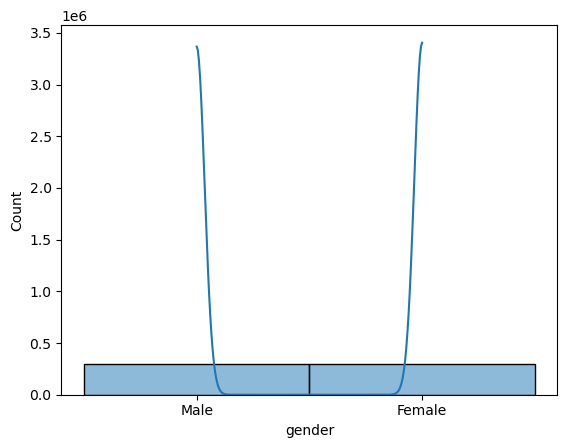

This there any null values: 0
------------------------------------------------------------------------------------------
The unique values are: ['Yes' 'No']
The number of unique values are: 2
The column name is: Partner
Partner
Yes    309554
No     284640
Name: count, dtype: int64
Partner
Yes    52.096453
No     47.903547
Name: proportion, dtype: float64
Partner  Churn
No       No       192240
         Yes       92400
Yes      No       268137
         Yes       41417
Name: count, dtype: int64
Partner  Churn
No       No       67.537943
         Yes      32.462057
Yes      No       86.620428
         Yes      13.379572
Name: proportion, dtype: float64
There is an significance difference betwedn the independent and dependent variable 0.0


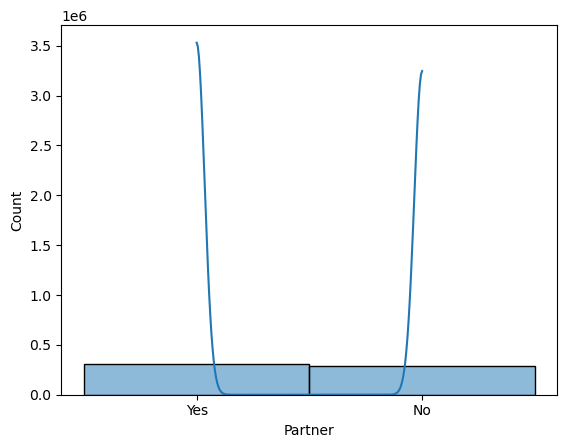

This there any null values: 0
------------------------------------------------------------------------------------------
The unique values are: ['Yes' 'No']
The number of unique values are: 2
The column name is: Dependents
Dependents
No     414362
Yes    179832
Name: count, dtype: int64
Dependents
No     69.735137
Yes    30.264863
Name: proportion, dtype: float64
Dependents  Churn
No          No       293636
            Yes      120726
Yes         No       166741
            Yes       13091
Name: count, dtype: int64
Dependents  Churn
No          No       70.864606
            Yes      29.135394
Yes         No       92.720428
            Yes       7.279572
Name: proportion, dtype: float64
There is an significance difference betwedn the independent and dependent variable 0.0


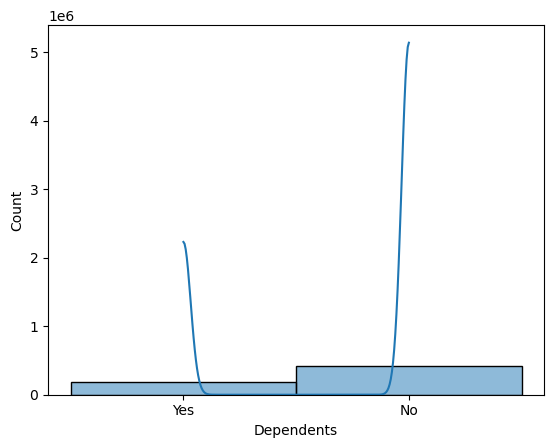

This there any null values: 0
------------------------------------------------------------------------------------------
The unique values are: ['Yes' 'No']
The number of unique values are: 2
The column name is: PhoneService
PhoneService
Yes    557893
No      36301
Name: count, dtype: int64
PhoneService
Yes    93.890716
No      6.109284
Name: proportion, dtype: float64
PhoneService  Churn
No            No        30197
              Yes        6104
Yes           No       430180
              Yes      127713
Name: count, dtype: int64
PhoneService  Churn
No            No       83.185036
              Yes      16.814964
Yes           No       77.107976
              Yes      22.892024
Name: proportion, dtype: float64
There is an significance difference betwedn the independent and dependent variable 8.013131829774979e-159


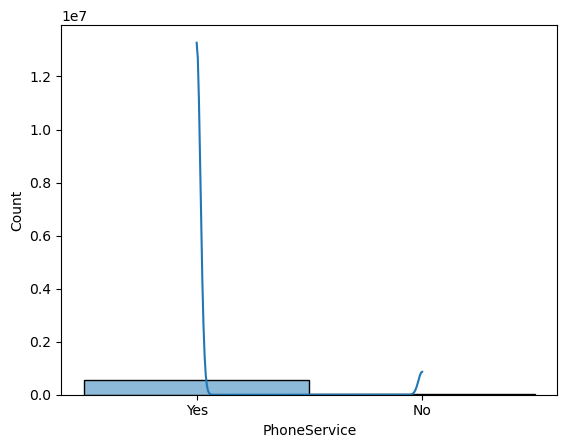

This there any null values: 0
------------------------------------------------------------------------------------------
The unique values are: ['No' 'Yes' 'No phone service']
The number of unique values are: 3
The column name is: MultipleLines
MultipleLines
No                  283384
Yes                 274509
No phone service     36301
Name: count, dtype: int64
MultipleLines
No                  47.692168
Yes                 46.198548
No phone service     6.109284
Name: proportion, dtype: float64
MultipleLines     Churn
No                No       231717
                  Yes       51667
No phone service  No        30197
                  Yes        6104
Yes               No       198463
                  Yes       76046
Name: count, dtype: int64
MultipleLines     Churn
No                No       81.767849
                  Yes      18.232151
No phone service  No       83.185036
                  Yes      16.814964
Yes               No       72.297447
                  Yes      27.7025

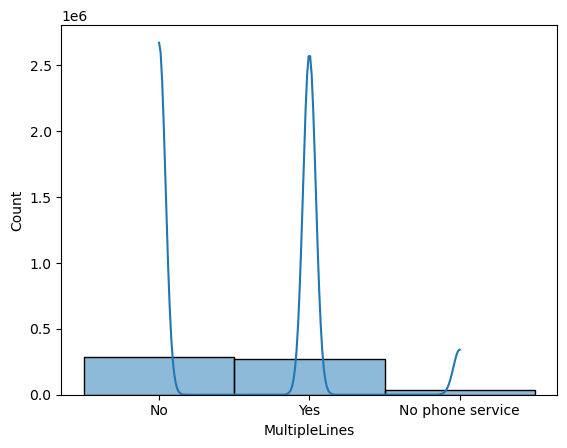

This there any null values: 0
------------------------------------------------------------------------------------------
The unique values are: ['DSL' 'Fiber optic' 'No']
The number of unique values are: 3
The column name is: InternetService
InternetService
Fiber optic    272386
DSL            181081
No             140727
Name: count, dtype: int64
InternetService
Fiber optic    45.841257
DSL            30.475064
No             23.683679
Name: proportion, dtype: float64
InternetService  Churn
DSL              No       162418
                 Yes       18663
Fiber optic      No       159246
                 Yes      113140
No               No       138713
                 Yes        2014
Name: count, dtype: int64
InternetService  Churn
DSL              No       89.693563
                 Yes      10.306437
Fiber optic      No       58.463357
                 Yes      41.536643
No               No       98.568860
                 Yes       1.431140
Name: proportion, dtype: float64
There i

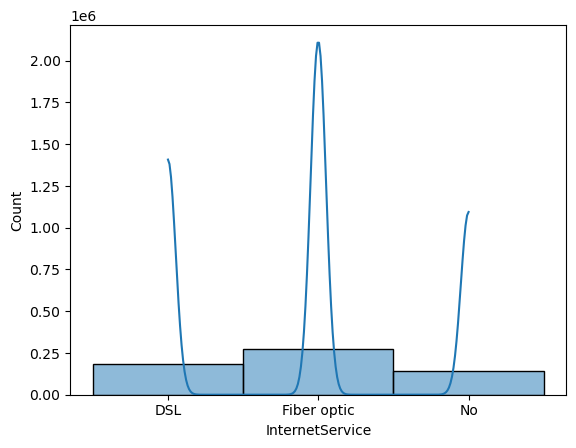

This there any null values: 0
------------------------------------------------------------------------------------------
The unique values are: ['Yes' 'No' 'No internet service']
The number of unique values are: 3
The column name is: OnlineSecurity
OnlineSecurity
No                     289474
Yes                    163993
No internet service    140727
Name: count, dtype: int64
OnlineSecurity
No                     48.717086
Yes                    27.599235
No internet service    23.683679
Name: proportion, dtype: float64
OnlineSecurity       Churn
No                   No       171909
                     Yes      117565
No internet service  No       138713
                     Yes        2014
Yes                  No       149755
                     Yes       14238
Name: count, dtype: int64
OnlineSecurity       Churn
No                   No       59.386681
                     Yes      40.613319
No internet service  No       98.568860
                     Yes       1.431140
Yes        

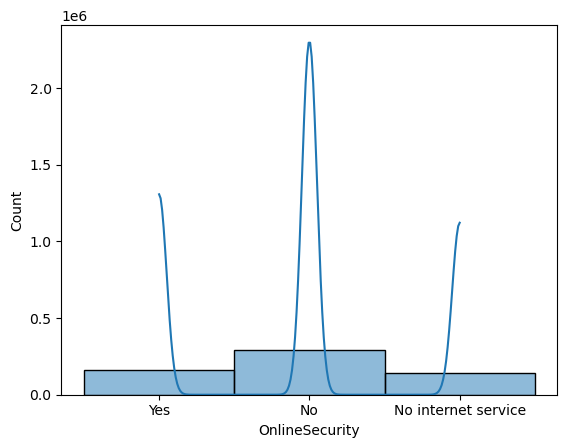

This there any null values: 0
------------------------------------------------------------------------------------------
The unique values are: ['No' 'Yes' 'No internet service']
The number of unique values are: 3
The column name is: OnlineBackup
OnlineBackup
No                     250083
Yes                    203384
No internet service    140727
Name: count, dtype: int64
OnlineBackup
No                     42.087769
Yes                    34.228552
No internet service    23.683679
Name: proportion, dtype: float64
OnlineBackup         Churn
No                   No       152294
                     Yes       97789
No internet service  No       138713
                     Yes        2014
Yes                  No       169370
                     Yes       34014
Name: count, dtype: int64
OnlineBackup         Churn
No                   No       60.897382
                     Yes      39.102618
No internet service  No       98.568860
                     Yes       1.431140
Yes              

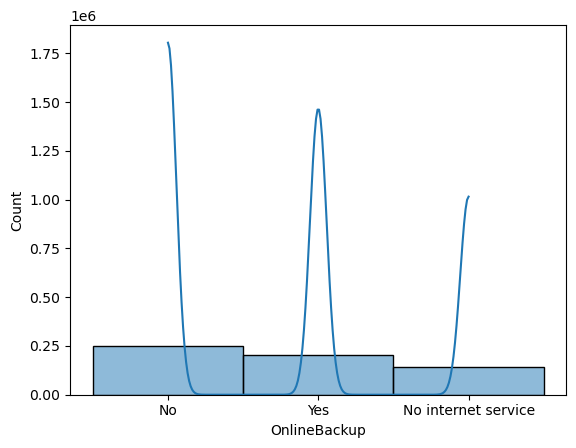

This there any null values: 0
------------------------------------------------------------------------------------------
The unique values are: ['Yes' 'No' 'No internet service']
The number of unique values are: 3
The column name is: DeviceProtection
DeviceProtection
No                     247377
Yes                    206090
No internet service    140727
Name: count, dtype: int64
DeviceProtection
No                     41.632362
Yes                    34.683958
No internet service    23.683679
Name: proportion, dtype: float64
DeviceProtection     Churn
No                   No       153218
                     Yes       94159
No internet service  No       138713
                     Yes        2014
Yes                  No       168446
                     Yes       37644
Name: count, dtype: int64
DeviceProtection     Churn
No                   No       61.937043
                     Yes      38.062957
No internet service  No       98.568860
                     Yes       1.431140
Yes  

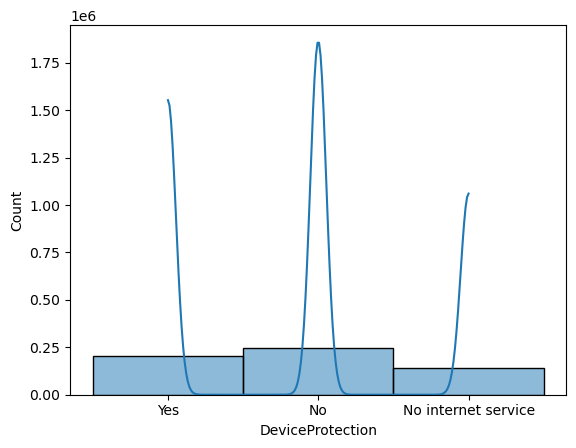

This there any null values: 0
------------------------------------------------------------------------------------------
The unique values are: ['Yes' 'No' 'No internet service']
The number of unique values are: 3
The column name is: TechSupport
TechSupport
No                     288571
Yes                    164896
No internet service    140727
Name: count, dtype: int64
TechSupport
No                     48.565115
Yes                    27.751206
No internet service    23.683679
Name: proportion, dtype: float64
TechSupport          Churn
No                   No       172675
                     Yes      115896
No internet service  No       138713
                     Yes        2014
Yes                  No       148989
                     Yes       15907
Name: count, dtype: int64
TechSupport          Churn
No                   No       59.837960
                     Yes      40.162040
No internet service  No       98.568860
                     Yes       1.431140
Yes                 

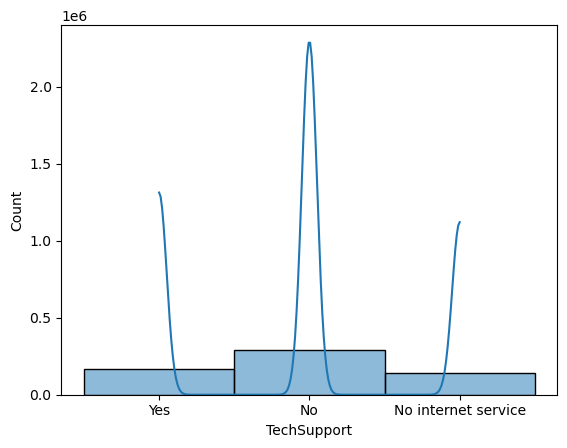

This there any null values: 0
------------------------------------------------------------------------------------------
The unique values are: ['No' 'Yes' 'No internet service']
The number of unique values are: 3
The column name is: StreamingTV
StreamingTV
Yes                    240301
No                     213166
No internet service    140727
Name: count, dtype: int64
StreamingTV
Yes                    40.441506
No                     35.874815
No internet service    23.683679
Name: proportion, dtype: float64
StreamingTV          Churn
No                   No       149767
                     Yes       63399
No internet service  No       138713
                     Yes        2014
Yes                  No       171897
                     Yes       68404
Name: count, dtype: int64
StreamingTV          Churn
No                   No       70.258390
                     Yes      29.741610
No internet service  No       98.568860
                     Yes       1.431140
Yes                 

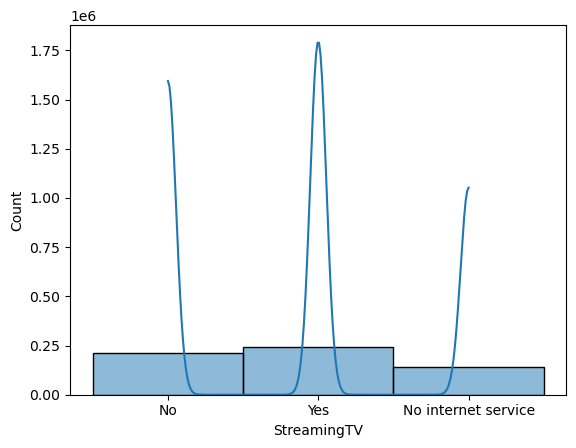

This there any null values: 0
------------------------------------------------------------------------------------------
The unique values are: ['No' 'Yes' 'No internet service']
The number of unique values are: 3
The column name is: StreamingMovies
StreamingMovies
Yes                    241435
No                     212032
No internet service    140727
Name: count, dtype: int64
StreamingMovies
Yes                    40.632352
No                     35.683969
No internet service    23.683679
Name: proportion, dtype: float64
StreamingMovies      Churn
No                   No       148571
                     Yes       63461
No internet service  No       138713
                     Yes        2014
Yes                  No       173093
                     Yes       68342
Name: count, dtype: int64
StreamingMovies      Churn
No                   No       70.070084
                     Yes      29.929916
No internet service  No       98.568860
                     Yes       1.431140
Yes     

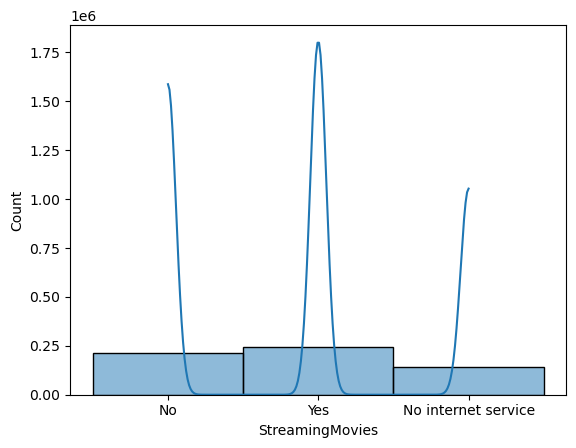

This there any null values: 0
------------------------------------------------------------------------------------------
The unique values are: ['One year' 'Two year' 'Month-to-month']
The number of unique values are: 3
The column name is: Contract
Contract
Month-to-month    298918
Two year          186943
One year          108333
Name: count, dtype: int64
Contract
Month-to-month    50.306466
Two year          31.461610
One year          18.231924
Name: proportion, dtype: float64
Contract        Churn
Month-to-month  No       173210
                Yes      125708
One year        No       102090
                Yes        6243
Two year        No       185077
                Yes        1866
Name: count, dtype: int64
Contract        Churn
Month-to-month  No       57.945657
                Yes      42.054343
One year        No       94.237213
                Yes       5.762787
Two year        No       99.001835
                Yes       0.998165
Name: proportion, dtype: float64
There is a

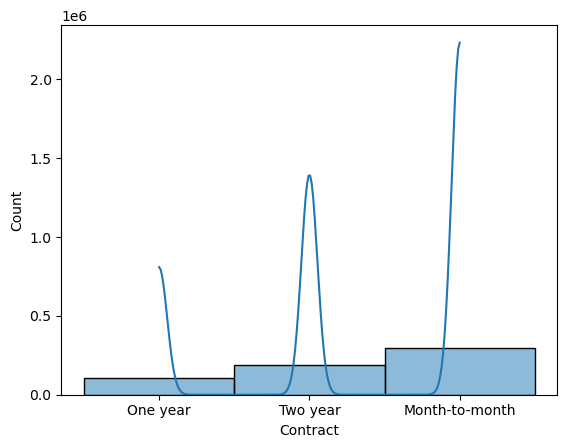

This there any null values: 0
------------------------------------------------------------------------------------------
The unique values are: ['Yes' 'No']
The number of unique values are: 2
The column name is: PaperlessBilling
PaperlessBilling
Yes    365579
No     228615
Name: count, dtype: int64
PaperlessBilling
Yes    61.525192
No     38.474808
Name: proportion, dtype: float64
PaperlessBilling  Churn
No                No       211559
                  Yes       17056
Yes               No       248818
                  Yes      116761
Name: count, dtype: int64
PaperlessBilling  Churn
No                No       92.539422
                  Yes       7.460578
Yes               No       68.061349
                  Yes      31.938651
Name: proportion, dtype: float64
There is an significance difference betwedn the independent and dependent variable 0.0


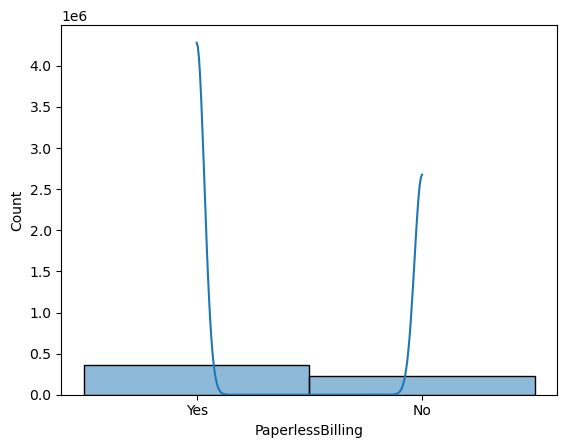

This there any null values: 0
------------------------------------------------------------------------------------------
The unique values are: ['Mailed check' 'Credit card (automatic)' 'Electronic check'
 'Bank transfer (automatic)']
The number of unique values are: 4
The column name is: PaymentMethod
PaymentMethod
Electronic check             215372
Credit card (automatic)      133705
Mailed check                 123757
Bank transfer (automatic)    121360
Name: count, dtype: int64
PaymentMethod
Electronic check             36.246075
Credit card (automatic)      22.501910
Mailed check                 20.827709
Bank transfer (automatic)    20.424306
Name: proportion, dtype: float64
PaymentMethod              Churn
Bank transfer (automatic)  No       112004
                           Yes        9356
Credit card (automatic)    No       124435
                           Yes        9270
Electronic check           No       110044
                           Yes      105328
Mailed check      

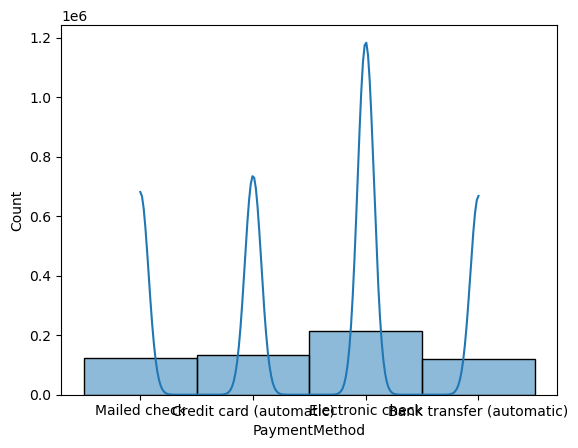

This there any null values: 0
------------------------------------------------------------------------------------------


In [57]:
for i in ind:
    if i!='Churn':
        print('The unique values are:',train[i].unique())
        print('The number of unique values are:',train[i].nunique())
        print('The column name is:',i)
        print(train[i].value_counts())
        print(train[i].value_counts(normalize=True)*100)
        print(train.groupby(i)['Churn'].value_counts())
        print(train.groupby(i)['Churn'].value_counts(normalize=True)*100)
        chi_test=pd.crosstab(train[i],train.Churn)
        if chi2_contingency(chi_test).pvalue<0.05:
            print('There is an significance difference betwedn the independent and dependent variable',chi2_contingency(chi_test).pvalue)
        else:
            print('There is no significance difference between the independent and dependent variable',chi2_contingency(chi_test).pvalue)
        sns.histplot(train[i], kde=True)
        plt.show()   
        print('This there any null values:',train[i].isnull().sum())
        print('---'*30)

In [58]:
if chi2_contingency(ct_blue).pvalue <0.05:
    print('There is a significant difference betwwen the independenp variable and dependent valiable')
else:
    print('There is no significant difference betwwen the independenp variable and dependent valiable')


There is a significant difference betwwen the independenp variable and dependent valiable


In [59]:
#### Encoding

In [60]:
train['Churn'].replace({'Yes':1,'No':0},inplace=True)

In [61]:
train.drop(columns='id',axis=1,inplace=True)

In [64]:
# 1. Avg monthly spend
train['AvgCharges'] = train['TotalCharges'] / (train['tenure'] + 1)
test['AvgCharges'] = test['TotalCharges'] / (test['tenure'] + 1)

# 2. Charges ratio
train['ChargeRatio'] = train['MonthlyCharges'] / (train['AvgCharges'] + 1)
test['ChargeRatio'] = test['MonthlyCharges'] / (test['AvgCharges'] + 1)

# 3. Tenure bins
bins = [0,12,24,48,60,100]
train['TenureGroup'] = pd.cut(train['tenure'], bins=bins, labels=False)
test['TenureGroup'] = pd.cut(test['tenure'], bins=bins, labels=False)

In [65]:
train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgCharges,ChargeRatio,TenureGroup
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0,55.128333,1.070760,2
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0,64.037288,1.068618,3
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0,99.005932,1.003940,3
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1,35.350000,1.917469,0
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1,35.225000,1.944790,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,0,94.150000,1.025223,3
594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,0,92.906164,0.979169,4
594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,0,25.642466,0.915831,4
594192,Female,0,No,No,32,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.00,2847.20,0,86.278788,0.985348,2


#### Data Insights

#### Overall Churn Rate

In [68]:
churn_rate = train['Churn'].value_counts(normalize=True) * 100
print(churn_rate)

Churn
0    77.479241
1    22.520759
Name: proportion, dtype: float64


Less Churn but High churn → business problem

#### Gender vs Churn

In [69]:
pd.crosstab(train['gender'], train['Churn'], normalize='index') * 100

Churn,0,1
gender,,
Female,77.196406,22.803594
Male,77.765217,22.234783


#### Senior Citizen

In [71]:
pd.crosstab(train['SeniorCitizen'], train['Churn'], normalize='index') * 100

Churn,0,1
SeniorCitizen,,
0,81.022616,18.977384
1,49.968289,50.031711


#### Needs better support

#### Contract Type

In [72]:
pd.crosstab(train['Contract'], train['Churn'], normalize='index') * 100

Churn,0,1
Contract,,
Month-to-month,57.945657,42.054343
One year,94.237213,5.762787
Two year,99.001835,0.998165


#### Long-term contracts reduce churn

#### Payment Method

In [75]:
pd.crosstab(train['PaymentMethod'], train['Churn'], normalize='index') * 100

Churn,0,1
PaymentMethod,,
Bank transfer (automatic),92.290705,7.709295
Credit card (automatic),93.066826,6.933174
Electronic check,51.094850,48.905150
Mailed check,92.030350,7.969650


#### Auto-pay reduces churn

#### Monthly Charges

In [76]:
train.groupby('Churn')['MonthlyCharges'].mean()

Churn
0    61.293633
1    81.597525
Name: MonthlyCharges, dtype: float64

#### Churned customers have higher charges So we need to recude the price for reduction of churn

#### Tenure Analysis

In [79]:
train.groupby('Churn')['tenure'].mean()

Churn
0    42.231313
1    17.125343
Name: tenure, dtype: float64

#### Churned customers have low tenure

#### Services (Tech Support)

In [80]:
pd.crosstab(train['TechSupport'], train['Churn'], normalize='index') * 100

Churn,0,1
TechSupport,,
No,59.837960,40.162040
No internet service,98.568860,1.431140
Yes,90.353314,9.646686


#### No tech support → higher churn

#### Paperless Billing

In [81]:
pd.crosstab(train['PaperlessBilling'], train['Churn'], normalize='index') * 100

Churn,0,1
PaperlessBilling,,
No,92.539422,7.460578
Yes,68.061349,31.938651


#### There is higher churn

#### High-Risk Customers

In [84]:
high_risk = train[
    (train['Contract'] == 'Month-to-month') &
    (train['MonthlyCharges'] > 70) &
    (train['tenure'] < 12)
]

print(high_risk.shape)

(75696, 23)


In [65]:
new_train=pd.get_dummies(train,drop_first=True,dtype='int')

#### Model Building

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score,accuracy_score,classification_report,confusion_matrix

In [176]:
X=new_train.drop('Churn',axis=1)
y=new_train['Churn']

In [177]:
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.8,test_size=0.2,random_state=0)

In [178]:
new_train

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,AvgCharges,ChargeRatio,TenureGroup,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,29,60.10,1653.85,0,55.128333,1.070760,2,1,1,1,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,1,0,0,1
1,0,58,69.50,3778.20,0,64.037288,1.068618,3,1,1,1,1,0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,1,0,1,0,0
2,0,58,100.40,5841.35,0,99.005932,1.003940,3,1,1,0,1,0,1,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1,0,1,0
3,0,1,69.70,70.70,1,35.350000,1.917469,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0
4,0,1,70.45,70.45,1,35.225000,1.944790,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,0,57,97.55,5460.70,0,94.150000,1.025223,3,1,0,0,1,0,1,1,0,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,0,0,0
594190,0,72,91.95,6782.15,0,92.906164,0.979169,4,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,0,0,0
594191,0,72,24.40,1871.90,0,25.642466,0.915831,4,0,1,0,1,0,1,0,1,1,0,1,0,1,0,1,0,1,0,1,0,0,1,0,1,0,0
594192,0,32,86.00,2847.20,0,86.278788,0.985348,2,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0


In [179]:
X

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,AvgCharges,ChargeRatio,TenureGroup,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,29,60.10,1653.85,55.128333,1.070760,2,1,1,1,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,1,0,0,1
1,0,58,69.50,3778.20,64.037288,1.068618,3,1,1,1,1,0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,1,0,1,0,0
2,0,58,100.40,5841.35,99.005932,1.003940,3,1,1,0,1,0,1,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1,0,1,0
3,0,1,69.70,70.70,35.350000,1.917469,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0
4,0,1,70.45,70.45,35.225000,1.944790,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,0,57,97.55,5460.70,94.150000,1.025223,3,1,0,0,1,0,1,1,0,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,0,0,0
594190,0,72,91.95,6782.15,92.906164,0.979169,4,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,0,0,0
594191,0,72,24.40,1871.90,25.642466,0.915831,4,0,1,0,1,0,1,0,1,1,0,1,0,1,0,1,0,1,0,1,0,0,1,0,1,0,0
594192,0,32,86.00,2847.20,86.278788,0.985348,2,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0


In [71]:
y

0         0
1         0
2         0
3         1
4         1
         ..
594189    0
594190    0
594191    0
594192    0
594193    1
Name: Churn, Length: 594194, dtype: int64

In [72]:
from sklearn.linear_model import LogisticRegression

In [73]:
model1=LogisticRegression()
model1.fit(X,y)

LogisticRegression()

In [74]:
y_train_predict=model1.predict(X_train)

In [75]:
y_test_predict=model1.predict(X_test)

In [76]:
y_train_predict

array([0, 0, 0, ..., 0, 0, 1], dtype=int64)

In [77]:
y_test_predict

array([0, 1, 0, ..., 0, 0, 0], dtype=int64)

In [78]:
accuracy_score(y_train,y_train_predict)

0.8531897213661369

In [79]:
accuracy_score(y_test,y_test_predict)

0.8518920556383005

In [80]:
confusion_matrix(y_train,y_train_predict)

array([[335785,  32580],
       [ 37207,  69783]], dtype=int64)

In [81]:
confusion_matrix(y_test,y_test_predict)

array([[83812,  8200],
       [ 9401, 17426]], dtype=int64)

In [82]:
print(classification_report(y_train,y_train_predict))

              precision    recall  f1-score   support

           0       0.90      0.91      0.91    368365
           1       0.68      0.65      0.67    106990

    accuracy                           0.85    475355
   macro avg       0.79      0.78      0.79    475355
weighted avg       0.85      0.85      0.85    475355



In [83]:
print(classification_report(y_test,y_test_predict))

              precision    recall  f1-score   support

           0       0.90      0.91      0.90     92012
           1       0.68      0.65      0.66     26827

    accuracy                           0.85    118839
   macro avg       0.79      0.78      0.78    118839
weighted avg       0.85      0.85      0.85    118839



#### Random Forest

In [86]:
from sklearn.ensemble import RandomForestClassifier

In [99]:
model2=RandomForestClassifier()
model2.fit(X,y)

RandomForestClassifier()

In [100]:
importance = model2.feature_importances_
features = X.columns

feat_imp = pd.Series(importance, index=features).sort_values(ascending=False)

print(feat_imp)

MonthlyCharges                           0.135332
TotalCharges                             0.123070
ChargeRatio                              0.119227
tenure                                   0.116345
AvgCharges                               0.114202
PaymentMethod_Electronic check           0.071972
InternetService_Fiber optic              0.047814
TenureGroup                              0.043621
Contract_Two year                        0.028547
Contract_One year                        0.015996
gender_Male                              0.015937
PaperlessBilling_Yes                     0.014674
OnlineSecurity_Yes                       0.013644
Partner_Yes                              0.013368
TechSupport_Yes                          0.011554
OnlineBackup_Yes                         0.010765
SeniorCitizen                            0.010510
MultipleLines_Yes                        0.009893
DeviceProtection_Yes                     0.009588
Dependents_Yes                           0.008879


In [156]:
selected_features = [
    'MonthlyCharges',
    'TotalCharges',
    'ChargeRatio',
    'tenure',
    'AvgCharges',
    'PaymentMethod_Electronic check',
    'InternetService_Fiber optic',
    'TenureGroup',
    'Contract_Two year',
    'Contract_One year',
    'gender_Male',
    'PaperlessBilling_Yes',
    'OnlineSecurity_Yes',
    'Partner_Yes',
    'TechSupport_Yes',
    'OnlineBackup_Yes',
    'SeniorCitizen',
    'MultipleLines_Yes',
    'DeviceProtection_Yes',
    'Dependents_Yes',
    'StreamingTV_Yes',
    'InternetService_No',
    'StreamingMovies_Yes',
    'PaymentMethod_Credit card (automatic)'
]

In [157]:
df_encoded = pd.get_dummies(train, drop_first=True)

In [158]:
X = df_encoded[selected_features]
y = df_encoded['Churn']

In [159]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [160]:
model2=RandomForestClassifier(n_estimators=20, max_depth=5)
model2

RandomForestClassifier(max_depth=5, n_estimators=20)

In [161]:
model2.fit(X,y)

RandomForestClassifier(max_depth=5, n_estimators=20)

In [162]:
y_train_predict_re=model2.predict(X_train)

In [163]:
y_test_predict_re=model2.predict(X_test)

In [164]:
accuracy_score(y_test,y_test_predict_re)

0.8496873921860668

In [165]:
accuracy_score(y_train,y_train_predict_re)

0.848721481839888

In [166]:
confusion_matrix(y_train,y_train_predict)

array([[289049,  79393],
       [ 83943,  22970]], dtype=int64)

In [167]:
confusion_matrix(y_test,y_test_predict)

array([[72128, 19807],
       [21085,  5819]], dtype=int64)

In [168]:
print(classification_report(y_train,y_train_predict))

              precision    recall  f1-score   support

           0       0.77      0.78      0.78    368442
           1       0.22      0.21      0.22    106913

    accuracy                           0.66    475355
   macro avg       0.50      0.50      0.50    475355
weighted avg       0.65      0.66      0.65    475355



In [169]:
print(classification_report(y_test,y_test_predict))

              precision    recall  f1-score   support

           0       0.77      0.78      0.78     91935
           1       0.23      0.22      0.22     26904

    accuracy                           0.66    118839
   macro avg       0.50      0.50      0.50    118839
weighted avg       0.65      0.66      0.65    118839



#### This project does not require feature importance as the accuracy is decreasing as the features are reduced so all the features are selected 

In [181]:
from sklearn.ensemble import RandomForestClassifier

In [182]:
model3=RandomForestClassifier()
model3.fit(X,y)

RandomForestClassifier()

In [188]:
X=new_train.drop('Churn',axis=1)
y=new_train['Churn']

In [189]:
X

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,AvgCharges,ChargeRatio,TenureGroup,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,29,60.10,1653.85,55.128333,1.070760,2,1,1,1,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,1,0,0,1
1,0,58,69.50,3778.20,64.037288,1.068618,3,1,1,1,1,0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,1,0,1,0,0
2,0,58,100.40,5841.35,99.005932,1.003940,3,1,1,0,1,0,1,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1,0,1,0
3,0,1,69.70,70.70,35.350000,1.917469,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0
4,0,1,70.45,70.45,35.225000,1.944790,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,0,57,97.55,5460.70,94.150000,1.025223,3,1,0,0,1,0,1,1,0,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,0,0,0
594190,0,72,91.95,6782.15,92.906164,0.979169,4,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,0,0,0
594191,0,72,24.40,1871.90,25.642466,0.915831,4,0,1,0,1,0,1,0,1,1,0,1,0,1,0,1,0,1,0,1,0,0,1,0,1,0,0
594192,0,32,86.00,2847.20,86.278788,0.985348,2,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0


In [190]:
y

0         0
1         0
2         0
3         1
4         1
         ..
594189    0
594190    0
594191    0
594192    0
594193    1
Name: Churn, Length: 594194, dtype: int64

In [191]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [192]:
y_train_predict=model3.predict(X_train)

In [193]:
y_test_predict=model3.predict(X_test)

In [194]:
accuracy_score(y_test,y_test_predict)

0.9999663410159965

In [195]:
accuracy_score(y_train,y_train_predict)

0.9999705483270398

In [196]:
confusion_matrix(y_train,y_train_predict)

array([[368442,      0],
       [    14, 106899]], dtype=int64)

In [197]:
confusion_matrix(y_test,y_test_predict)

array([[91935,     0],
       [    4, 26900]], dtype=int64)

In [198]:
print(classification_report(y_train,y_train_predict))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    368442
           1       1.00      1.00      1.00    106913

    accuracy                           1.00    475355
   macro avg       1.00      1.00      1.00    475355
weighted avg       1.00      1.00      1.00    475355



In [199]:
print(classification_report(y_test,y_test_predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     91935
           1       1.00      1.00      1.00     26904

    accuracy                           1.00    118839
   macro avg       1.00      1.00      1.00    118839
weighted avg       1.00      1.00      1.00    118839



#### Save Model + Features

In [201]:
import pickle

# Save model
pickle.dump(model3, open('model.pkl', 'wb'))

# Save feature order
all_features = X.columns.tolist()
pickle.dump(all_features, open('features.pkl', 'wb'))

# Save default values (mean)
defaults = X.mean().to_dict()
pickle.dump(defaults, open('defaults.pkl', 'wb'))

#### HyperParameter Tunning Techinque

In [93]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# 🔥 SAMPLE DATA
X_sample = X_train.sample(100000, random_state=42)
y_sample = y_train.loc[X_sample.index]

params = {
    'n_estimators': [50, 100],       
    'max_depth': [5, 8],             
    'max_features': ['sqrt'],        
    'bootstrap': [True]
}

model = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    model,
    param_distributions=params,
    n_iter=3,            
    cv=2,                
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_sample, y_sample)

print("Best Params:", random_search.best_params_)

Fitting 2 folds for each of 3 candidates, totalling 6 fits
Best Params: {'n_estimators': 100, 'max_features': 'sqrt', 'max_depth': 8, 'bootstrap': True}


In [95]:
random_search.best_score_

0.9103901737982385

In [97]:
rf_best = random_search.best_estimator_

rf_pred = rf_best.predict_proba(X_test)[:,1]

print("RF ROC-AUC:", roc_auc_score(y_test, rf_pred))

RF ROC-AUC: 0.9091592623320895


In [99]:
rf_best.fit(X, y)

RandomForestClassifier(max_depth=8, random_state=42)

In [120]:
test_predicts=rf_best.predict(new_test)

In [121]:
test_predicts

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [122]:
final_pred = rf_best.predict_proba(new_test)

In [116]:
final_pred

array([0.08168246, 0.0022718 , 0.14059678, ..., 0.27558905, 0.00593857,
       0.30967767])

In [119]:
sample

,id,Churn
0,594194,0
1,594195,0
2,594196,0
3,594197,0
4,594198,0
...,...,...
254650,848844,0
254651,848845,0
254652,848846,0
254653,848847,0


#### Test

In [100]:
new_test=pd.get_dummies(test,drop_first=True,dtype='int')

In [101]:
new_test

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,594194,0,72,115.55,8061.50,0,1,0,1,0,1,1,0,0,1,0,1,0,1,0,1,0,1,0,1,0,1,1,0,1,0
1,594195,0,71,19.80,1336.50,0,1,0,1,0,0,0,1,1,0,1,0,1,0,1,0,1,0,1,0,0,1,0,0,0,0
2,594196,0,12,55.55,633.55,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
3,594197,0,71,84.10,6457.15,1,1,1,1,0,1,0,0,0,1,0,0,0,1,0,1,0,1,0,1,0,1,0,1,0,0
4,594198,0,15,90.35,1233.65,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254650,848844,0,72,19.95,1443.65,1,1,1,1,0,0,0,1,1,0,1,0,1,0,1,0,1,0,1,0,0,1,0,1,0,0
254651,848845,1,16,100.15,1563.50,1,1,0,1,0,1,1,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,1,0,1,0
254652,848846,0,35,105.80,3132.75,1,1,0,1,0,1,1,0,0,1,0,0,0,1,0,1,0,1,0,1,0,0,1,0,0,0
254653,848847,0,25,20.25,511.25,0,0,0,1,0,0,0,1,1,0,1,0,1,0,1,0,1,0,1,0,0,1,1,1,0,0


In [102]:
X

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,29,60.10,1653.85,1,1,1,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,1,0,0,1
1,0,58,69.50,3778.20,1,1,1,1,0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,1,0,1,0,0
2,0,58,100.40,5841.35,1,1,0,1,0,1,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1,0,1,0
3,0,1,69.70,70.70,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0
4,0,1,70.45,70.45,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,0,57,97.55,5460.70,1,0,0,1,0,1,1,0,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,0,0,0
594190,0,72,91.95,6782.15,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,0,0,0
594191,0,72,24.40,1871.90,0,1,0,1,0,1,0,1,1,0,1,0,1,0,1,0,1,0,1,0,0,1,0,1,0,0
594192,0,32,86.00,2847.20,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0


In [103]:
new_test.drop(columns='id',axis=1,inplace=True)

In [104]:
new_test

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,72,115.55,8061.50,0,1,0,1,0,1,1,0,0,1,0,1,0,1,0,1,0,1,0,1,0,1,1,0,1,0
1,0,71,19.80,1336.50,0,1,0,1,0,0,0,1,1,0,1,0,1,0,1,0,1,0,1,0,0,1,0,0,0,0
2,0,12,55.55,633.55,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
3,0,71,84.10,6457.15,1,1,1,1,0,1,0,0,0,1,0,0,0,1,0,1,0,1,0,1,0,1,0,1,0,0
4,0,15,90.35,1233.65,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254650,0,72,19.95,1443.65,1,1,1,1,0,0,0,1,1,0,1,0,1,0,1,0,1,0,1,0,0,1,0,1,0,0
254651,1,16,100.15,1563.50,1,1,0,1,0,1,1,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,1,0,1,0
254652,0,35,105.80,3132.75,1,1,0,1,0,1,1,0,0,1,0,0,0,1,0,1,0,1,0,1,0,0,1,0,0,0
254653,0,25,20.25,511.25,0,0,0,1,0,0,0,1,1,0,1,0,1,0,1,0,1,0,1,0,0,1,1,1,0,0


In [109]:
test_predict=model2.predict(new_test)

In [110]:
test_predict

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [123]:
submission =pd.DataFrame(test_predicts,columns=['Churn'])

In [124]:
submission['id']=sample['id']

In [125]:
submission

,Churn,id
0,0,594194
1,0,594195
2,0,594196
3,0,594197
4,1,594198
...,...,...
254650,0,848844
254651,1,848845
254652,0,848846
254653,0,848847


In [126]:
submission.to_csv("submission.csv", index=False)